# Time Series Clustering 🗂️

Time series clustering is the process of grouping similar time series data points together.
Unlike standard tabular clustering (like K-Means on house prices), time series data has a temporal dimension. If two identical signals are shifted by just one time step, standard Euclidean distance will say they are completely different!

To solve this, we use **Dynamic Time Warping (DTW)**. DTW "warps" the time axis to align two sequences optimally before computing their distance.

In this notebook, we'll:
1. Load a dataset of different heartbeats.
2. Install and use the `tslearn` library.
3. Cluster the sequences using K-Means with the DTW distance metric.
4. Visualize the discovered clusters.

In [1]:
# Install tslearn directly in the notebook
!pip install tslearn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
import warnings
warnings.filterwarnings('ignore')

/Users/ajitkumarsingh/opt/anaconda3/envs/ts_1/lib/python3.9/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


## 1. Load Data

We'll use the `ECG200` dataset, which contains 100 electrical activity sequences of heartbeats. Some are normal, some are abnormal (Myocardial Infarction). We want to see if our clustering algorithm can discover these two distinct groups automatically.

Features shape: (100, 96)
Labels shape: (100,)


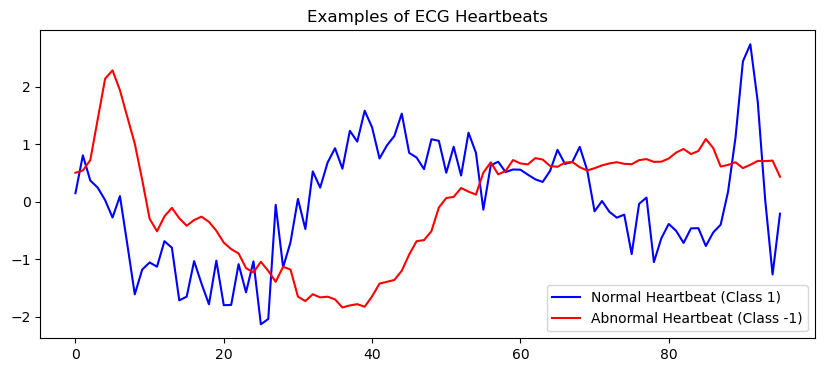

In [3]:
# Load the dataset
df_train = pd.read_csv('data/ECG200_TRAIN.tsv', sep='	', header=None)

# Column 0 is the label (1 for normal, -1 for abnormal)
y = df_train.iloc[:, 0].values
X = df_train.iloc[:, 1:].values

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

# Let's plot one of each class
plt.figure(figsize=(10,4))
plt.plot(X[y == 1][0], label='Normal Heartbeat (Class 1)', color='blue')
plt.plot(X[y == -1][0], label='Abnormal Heartbeat (Class -1)', color='red')
plt.title('Examples of ECG Heartbeats')
plt.legend()
plt.show()

## 2. Preprocessing

For clustering based on shape rather than amplitude, it is crucial to normalize the sequences to have a mean of 0 and a standard deviation of 1.

In [4]:
# tslearn requires data to be in shape (n_samples, sequence_length, dimensionality)
# Our dimensionality is 1 (univariate time series)
X_reshaped = X.reshape((X.shape[0], X.shape[1], 1))

# Scale the time series
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X_reshaped)

print(f"Scaled shape: {X_scaled.shape}")

Scaled shape: (100, 96, 1)


## 3. Clustering with DTW K-Means

We will use `TimeSeriesKMeans` from `tslearn`. We set `metric="dtw"` to use Dynamic Time Warping instead of standard Euclidean distance. We ask for 2 clusters since we know there are 2 underlying classes (Normal vs Abnormal).

In [5]:
# Initialize the model
# metric="dtw" is the magic that handles temporal shifts
model = TimeSeriesKMeans(n_clusters=2, metric="dtw", max_iter=10, random_state=42)

# Fit and Predict
y_pred = model.fit_predict(X_scaled)

print("Clustering complete!")

Clustering complete!


## 4. Visualization of Clusters

Let's visualize the shape of the clusters. `TimeSeriesKMeans` computes the "barycenter" (the average sequence) for each cluster using DTW space.

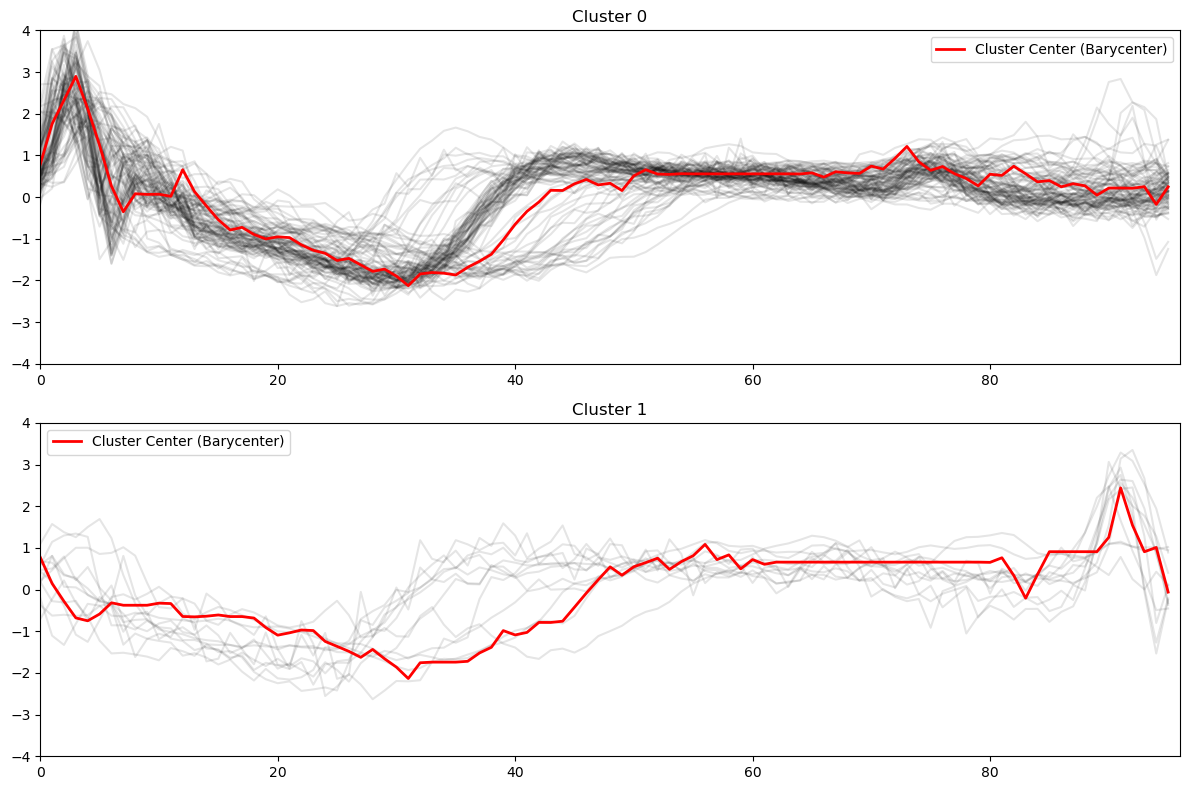

In [6]:
plt.figure(figsize=(12, 8))

for cluster_id in range(2):
    plt.subplot(2, 1, cluster_id + 1)
    
    # Plot all sequences in this cluster
    for xx in X_scaled[y_pred == cluster_id]:
        plt.plot(xx.ravel(), "k-", alpha=0.1)
    
    # Plot the cluster center (barycenter)
    plt.plot(model.cluster_centers_[cluster_id].ravel(), "r-", linewidth=2, label="Cluster Center (Barycenter)")
    
    plt.title(f"Cluster {cluster_id}")
    plt.xlim(0, X_scaled.shape[1])
    plt.ylim(-4, 4)
    plt.legend()

plt.tight_layout()
plt.show()

### Conclusion
By using **DTW K-Means**, the algorithm was able to successfully group the heartbeat signals into two distinct shape profiles, closely matching the normal and abnormal biological patterns, despite natural variations in timing and speed!